

 # **1. Introduction**

---




This project focuses on anomaly detection in vehicle telemetry time-series data using machine learning techniques.

The dataset contains simulated sequential telemetry measurements collected from a vehicle over time. The telemetry features include vehicle speed, acceleration, brake pressure, steering angle, lane offset, engine temperature, and driver attention score.

In addition to normal driving behavior, the dataset includes several abnormal driving patterns such as harsh braking, lane drifting, distracted driving, and engine overheating events.

Since vehicle telemetry is inherently time-dependent, temporal behavior plays an important role in understanding anomalies. Sudden changes, unstable driving patterns, and abnormal transitions over time are critical indicators of unsafe driving conditions.

The objective of this project is to:

perform exploratory data analysis (EDA) on telemetry time-series data,
analyze anomaly behavior across different feature spaces,
engineer meaningful telemetry features,
and build an anomaly detection pipeline using the Isolation Forest algorithm to identify abnormal driving behavior.


# **2. Load & Inspect Data**

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/vehicle_telemetry.csv",parse_dates=["timestamp"])

In [3]:
df.head()

,timestamp,speed_kmh,acceleration_ms2,brake_pressure_pct,steering_angle_deg,lane_offset_m,engine_temp_c,driver_attention,label
0,2026-05-09 08:00:00.000,60.0,0.860,0.0,0.00,0.000,70.0,0.950,normal
1,2026-05-09 08:00:00.100,60.3,0.596,0.0,-0.06,0.016,70.0,0.945,normal
2,2026-05-09 08:00:00.200,60.5,0.913,0.0,-0.60,0.036,70.0,0.941,normal
3,2026-05-09 08:00:00.300,61.0,2.522,0.0,-1.29,0.043,70.1,0.927,normal
4,2026-05-09 08:00:00.400,62.3,3.121,0.0,-2.00,0.069,70.2,0.916,normal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           10000 non-null  datetime64[ns]
 1   speed_kmh           10000 non-null  float64       
 2   acceleration_ms2    10000 non-null  float64       
 3   brake_pressure_pct  10000 non-null  float64       
 4   steering_angle_deg  10000 non-null  float64       
 5   lane_offset_m       10000 non-null  float64       
 6   engine_temp_c       10000 non-null  float64       
 7   driver_attention    10000 non-null  float64       
 8   label               10000 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 703.3+ KB


In [5]:
df.shape

(10000, 9)

In [6]:
df.describe()

,timestamp,speed_kmh,acceleration_ms2,brake_pressure_pct,steering_angle_deg,lane_offset_m,engine_temp_c,driver_attention
count,10000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2026-05-09 08:08:19.950000128,66.101920,-0.185854,13.22893,-8.933870,0.025987,75.231680,0.808614
min,2026-05-09 08:00:00,0.000000,-8.978000,0.00000,-45.120000,-1.581000,70.000000,0.101000
25%,2026-05-09 08:04:09.975000064,28.300000,-1.703000,0.00000,-32.202500,-0.313000,72.500000,0.693000
50%,2026-05-09 08:08:19.950000128,64.050000,-0.016500,0.30000,-14.765000,0.038000,74.200000,0.828000
75%,2026-05-09 08:12:29.924999936,101.125000,1.432000,20.40000,15.422500,0.365000,77.100000,0.944000
max,2026-05-09 08:16:39.900000,140.000000,8.094000,100.00000,51.210000,1.552000,123.100000,1.000000
std,NaN,42.738797,2.637747,20.96537,26.923063,0.368765,4.422826,0.156711


# **3. Missing Values / Data Quality**

In [7]:
df.isnull().sum()

,0
timestamp,0
speed_kmh,0
acceleration_ms2,0
brake_pressure_pct,0
steering_angle_deg,0
lane_offset_m,0
engine_temp_c,0
driver_attention,0
label,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

,0
timestamp,datetime64[ns]
speed_kmh,float64
acceleration_ms2,float64
brake_pressure_pct,float64
steering_angle_deg,float64
lane_offset_m,float64
engine_temp_c,float64
driver_attention,float64
label,object


In [10]:
df[df["speed_kmh"] < 0]

,timestamp,speed_kmh,acceleration_ms2,brake_pressure_pct,steering_angle_deg,lane_offset_m,engine_temp_c,driver_attention,label


In [11]:
df[df["engine_temp_c"] > 200]

,timestamp,speed_kmh,acceleration_ms2,brake_pressure_pct,steering_angle_deg,lane_offset_m,engine_temp_c,driver_attention,label


In [12]:
df[
    (df["driver_attention"] < 0) |
    (df["driver_attention"] > 1)
]

,timestamp,speed_kmh,acceleration_ms2,brake_pressure_pct,steering_angle_deg,lane_offset_m,engine_temp_c,driver_attention,label


In [13]:
df = df[df["speed_kmh"] >= 0]

In [14]:
df["time_diff"] = (
    df["timestamp"]
    .diff()
    .dt.total_seconds()
)

The data doesn't contain any unrealstic readings such as sensor noise which aligns with the fact that this data is generated and is not real sensor readings

# **4. Feature Distributions**

In [15]:
df["label"].value_counts()

,count
label,
normal,9199
harsh_braking,269
distracted_driving,234
overheating,183
lane_drifting,115


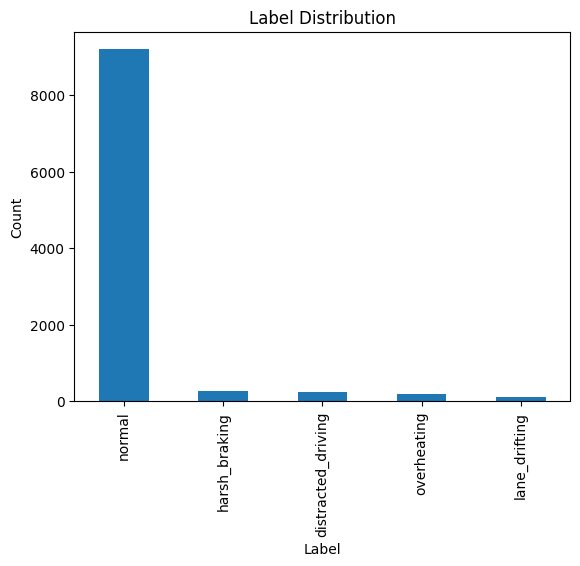

In [16]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

The normal represents most of the data and the anomalies are rare which aligns with anomaly detection problem statment

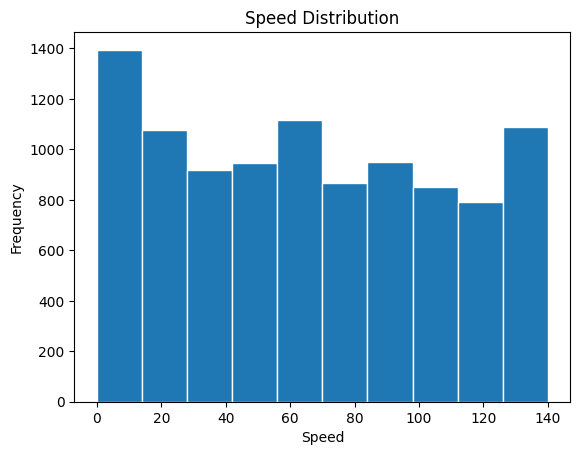

In [17]:

plt.hist(df["speed_kmh"], edgecolor='white')
plt.title("Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

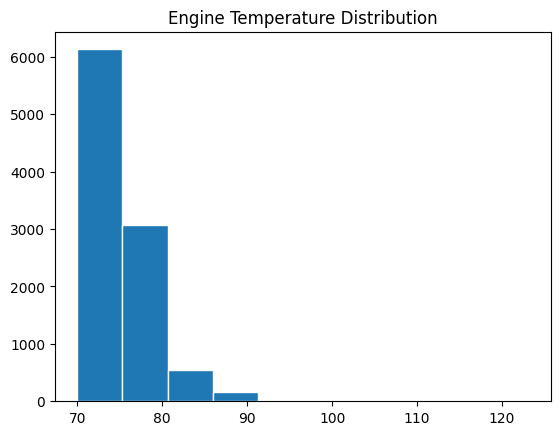

In [31]:
plt.hist(df["engine_temp_c"], edgecolor='white')

plt.title("Engine Temperature Distribution")

plt.show()

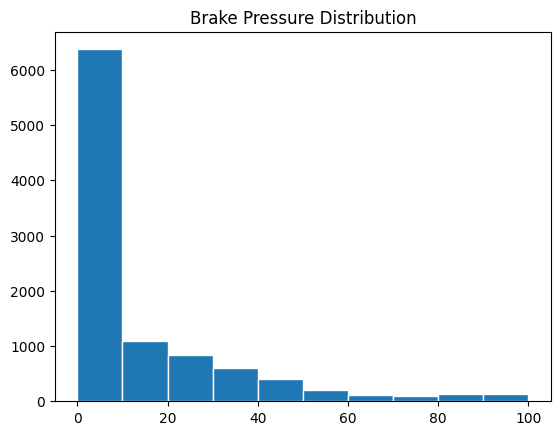

In [33]:
plt.hist(df["brake_pressure_pct"], edgecolor='white')

plt.title("Brake Pressure Distribution")

plt.show()

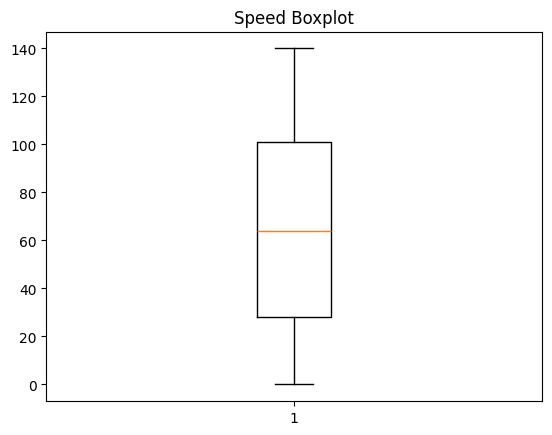

In [20]:
plt.boxplot(df["speed_kmh"])
plt.title("Speed Boxplot")

plt.show()

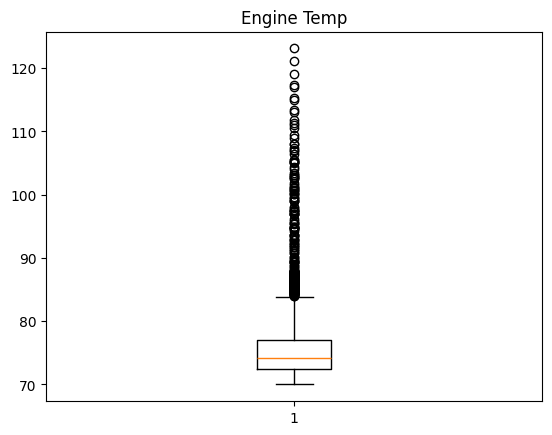

In [21]:
plt.boxplot(df["engine_temp_c"])
plt.title("Engine Temp")

plt.show()

The engine temperature distribution is concentrated within a narrow normal range, while several high-temperature outliers may correspond to overheating anomalies.

# **5. Correlation Matrix**



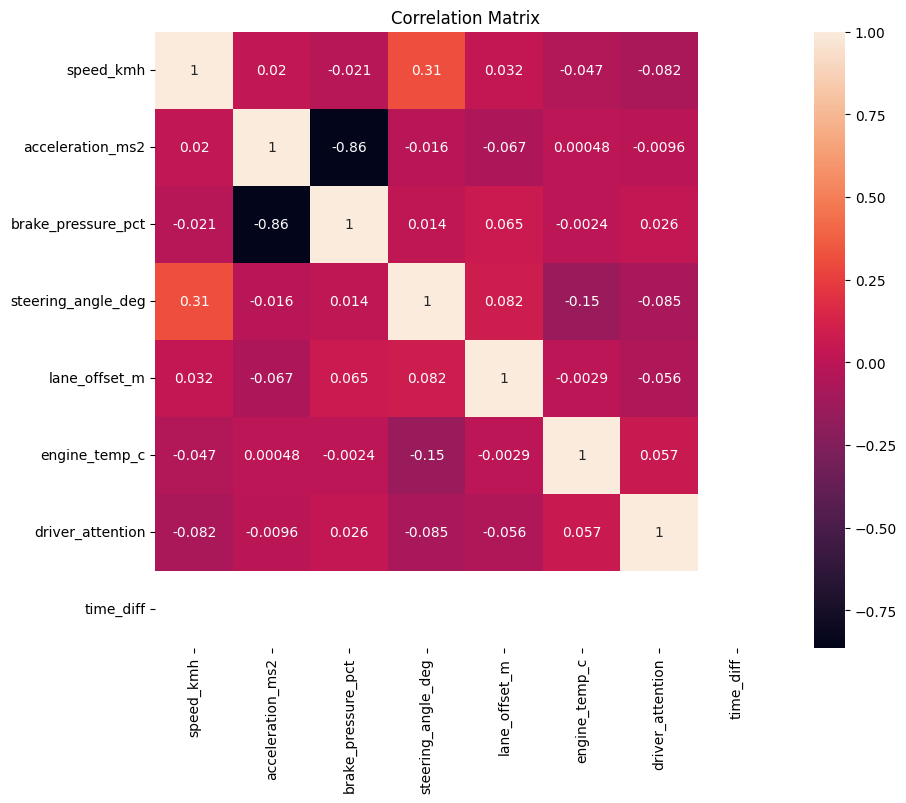

In [22]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

Most telemetry features exhibit weak correlations, indicating that they capture different aspects of vehicle behavior. The strongest relationship is the strong negative correlation between brake pressure and acceleration, which reflects realistic braking dynamics.

# **5. Relationship Analysis**

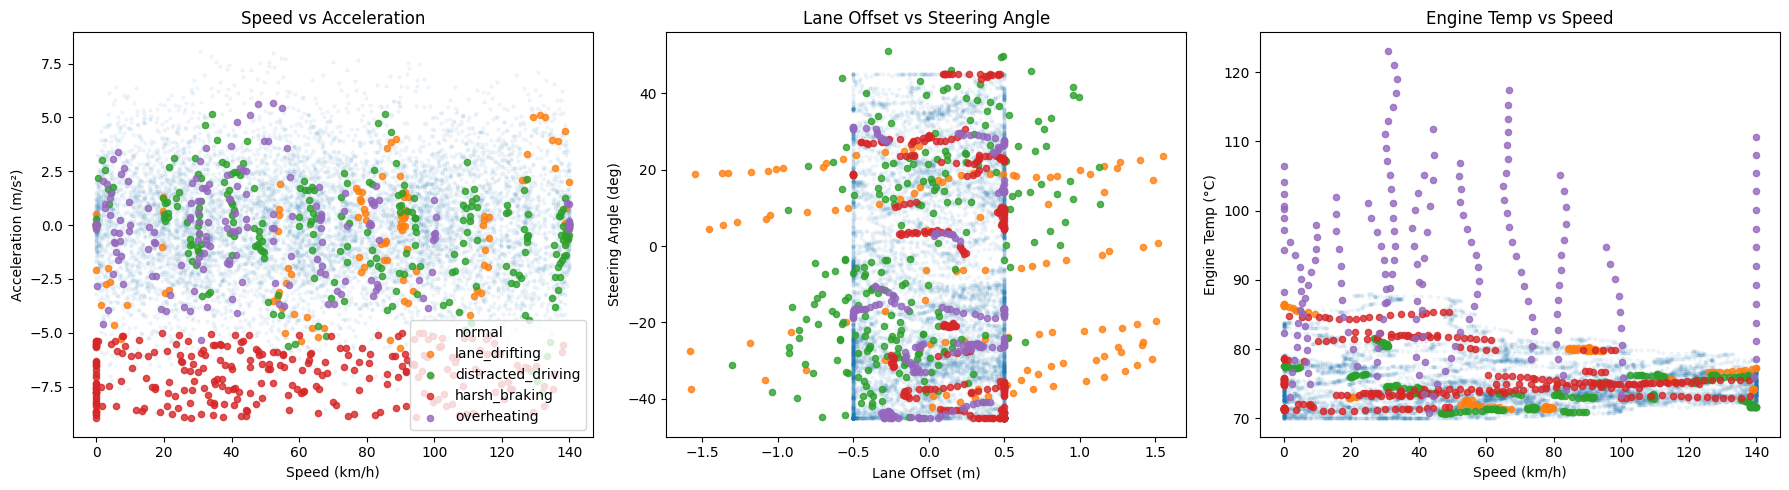

In [34]:
import matplotlib.pyplot as plt

labels = df["label"].unique()

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------------
# Plot settings helper
# -----------------------------------

for label in labels:

    subset = df[df["label"] == label]

    # Make normal points lighter
    if label == "normal":
        alpha = 0.05
        size = 5
    else:
        alpha = 0.8
        size = 20

    # -----------------------------------
    # 1) Speed vs Acceleration
    # -----------------------------------

    axes[0].scatter(
        subset["speed_kmh"],
        subset["acceleration_ms2"],
        alpha=alpha,
        s=size,
        label=label
    )

    # -----------------------------------
    # 2) Lane Offset vs Steering Angle
    # -----------------------------------

    axes[1].scatter(
        subset["lane_offset_m"],
        subset["steering_angle_deg"],
        alpha=alpha,
        s=size,
        label=label
    )

    # -----------------------------------
    # 3) Engine Temp vs Speed
    # -----------------------------------

    axes[2].scatter(
        subset["speed_kmh"],
        subset["engine_temp_c"],
        alpha=alpha,
        s=size,
        label=label
    )

# -----------------------------------
# Titles and labels
# -----------------------------------

axes[0].set_title("Speed vs Acceleration")
axes[0].set_xlabel("Speed (km/h)")
axes[0].set_ylabel("Acceleration (m/s²)")

axes[1].set_title("Lane Offset vs Steering Angle")
axes[1].set_xlabel("Lane Offset (m)")
axes[1].set_ylabel("Steering Angle (deg)")

axes[2].set_title("Engine Temp vs Speed")
axes[2].set_xlabel("Speed (km/h)")
axes[2].set_ylabel("Engine Temp (°C)")

# Add legend to first plot only
axes[0].legend()

plt.tight_layout()
plt.show()

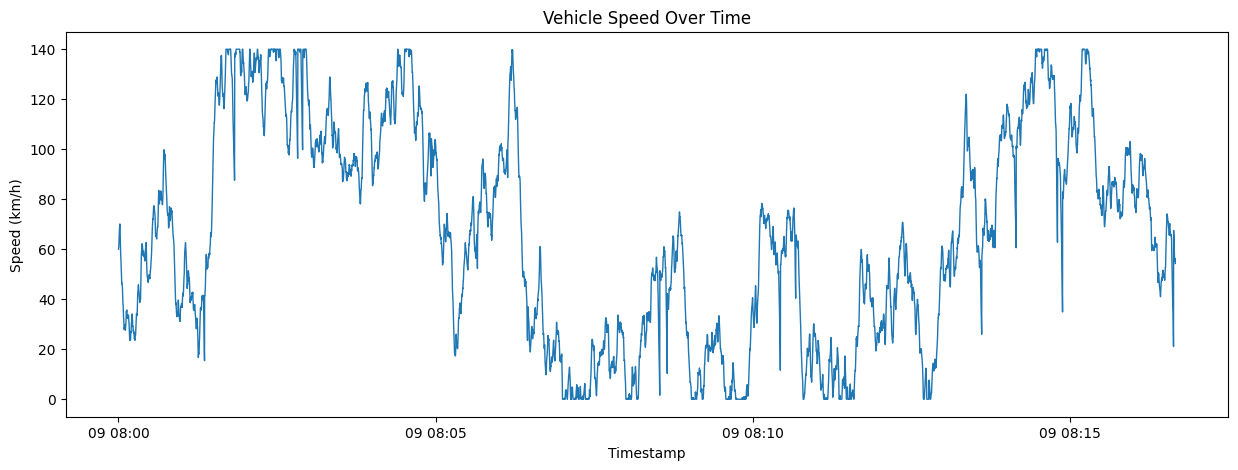

In [23]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["speed_kmh"],
    linewidth=1
)

plt.title("Vehicle Speed Over Time")

plt.xlabel("Timestamp")

plt.ylabel("Speed (km/h)")

plt.show()

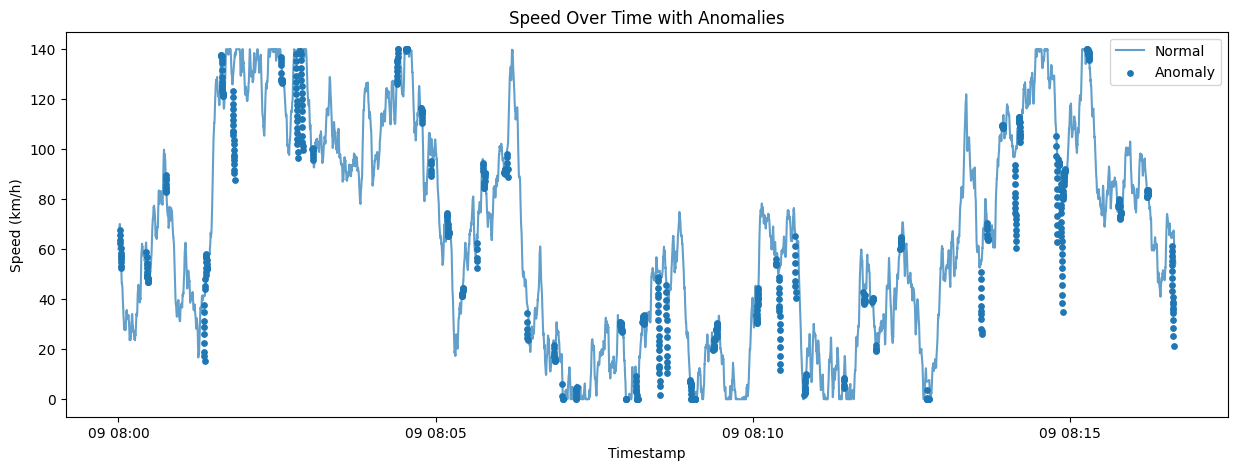

In [25]:
plt.figure(figsize=(15,5))

plt.plot(
    normal["timestamp"],
    normal["speed_kmh"],
    alpha=0.7
)

plt.scatter(
    anomaly["timestamp"],
    anomaly["speed_kmh"],
    s=15
)

plt.title("Speed Over Time with Anomalies")

plt.xlabel("Timestamp")

plt.ylabel("Speed (km/h)")

plt.legend(["Normal", "Anomaly"])

plt.show()

The exploratory analysis showed that different anomaly categories become distinguishable in different telemetry feature spaces.

Harsh braking events appeared clearly at strongly negative acceleration values and were relatively separable from normal driving behavior in the speed–acceleration space. Lane drifting anomalies exhibited larger lane offsets and wider steering-angle variation compared to normal driving patterns. Overheating events were associated with unusually high engine temperature values across multiple driving speeds.

The analysis also revealed significant overlap between several anomaly categories and normal driving behavior when visualized in only two dimensions. This suggests that many telemetry anomalies are not linearly separable and require multi-feature analysis rather than single-feature thresholding approaches.
